# Phase 3: Preprocessing, EDA, and Modeling

## NYC Taxi Fare Prediction Using Big Data Analytics

This notebook continues Phase 3 of the project.

The previous Spark processing notebook inspected the full 2024 Yellow Taxi raw dataset and identified several data quality issues, including missing values, abnormal timestamps, invalid passenger counts, zero or negative trip distances, negative fare values, and invalid trip durations.

In this notebook, we will:

- Load the full 2024 Yellow Taxi dataset using Spark
- Apply preprocessing rules
- Create useful features
- Save the cleaned dataset
- Perform exploratory data analysis
- Build a fare prediction model using Spark MLlib / Spark Pipeline
- Evaluate the model using regression metrics

Unlike the previous notebook, this notebook will actually clean and transform the data.

## 1. Import Required Libraries

In this step, we import the libraries needed for Spark processing, data cleaning, feature engineering, and machine learning.

Spark will be used as the main Big Data processing framework for this notebook.

In [1]:
from pathlib import Path

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    lit,
    unix_timestamp,
    hour,
    dayofweek,
    month,
    when
)

print("Required libraries imported successfully.")

Required libraries imported successfully.


## 2. Define Project and Data Paths

In this step, we define the HDFS paths for the raw and processed datasets.

Raw data is stored in HDFS at `hdfs://namenode:9000/taxi/raw/` as 12 monthly Parquet files.

Processed data will be saved to `hdfs://namenode:9000/taxi/processed/`.

Output files (figures, metrics) are saved to `/home/jovyan/notebooks/outputs/`.

In [2]:
# HDFS paths — data lives in HDFS, not on the local machine
HDFS_NAMENODE  = "hdfs://namenode:9000"
HDFS_RAW       = f"{HDFS_NAMENODE}/taxi/raw"
HDFS_PROCESSED = f"{HDFS_NAMENODE}/taxi/processed"
HDFS_MODEL     = f"{HDFS_NAMENODE}/taxi/model/lr_pipeline_model"

# Local output paths inside Docker Jupyter
from pathlib import Path
OUTPUTS_DIR = Path("/home/jovyan/notebooks/outputs")
FIGURES_DIR = OUTPUTS_DIR / "figures"
MODEL_DIR   = OUTPUTS_DIR / "model_results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("HDFS raw path      :", HDFS_RAW)
print("HDFS processed path:", HDFS_PROCESSED)
print("Local outputs dir  :", OUTPUTS_DIR)

## 3. Start Spark Session

In this step, we start a Spark session.

Spark will be used as the main Big Data processing framework for preprocessing, feature engineering, EDA, and machine learning.

This step only starts Spark. It does not load or modify the dataset yet.

In [3]:
# Running inside Docker — HADOOP_HOME is pre-configured in the container.
# No manual environment setup is needed.
print("Running inside Docker Jupyter — Hadoop environment pre-configured.")

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NYC_Taxi_Preprocessing_EDA_Modeling") \
    .config("spark.executor.memory", "2g") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Spark session started successfully.")
print("Spark version:", spark.version)
print("Spark master :", spark.sparkContext.master)

## 4. Load the 2024 Yellow Taxi Dataset from HDFS

In this step, we load the full 2024 Yellow Taxi dataset from HDFS.

The data was uploaded to HDFS using `hdfs_setup.py` and is stored at
`hdfs://namenode:9000/taxi/raw/` as 12 monthly Parquet files.

Spark reads all 12 files from HDFS as a single unified DataFrame.

In [5]:
# Load all 12 monthly Parquet files from HDFS
taxi_df = spark.read.parquet(HDFS_RAW)

print("2024 Yellow Taxi dataset loaded from HDFS:")
print("  Path:", HDFS_RAW)
print("  Rows:", taxi_df.count())
print("  Cols:", len(taxi_df.columns))

## 5. Confirm Raw Dataset Size

In this step, we count the number of rows and columns in the raw 2024 Yellow Taxi dataset after loading it with Spark.

This gives us the baseline size before applying any preprocessing rules.

Later, after cleaning, we will compare the cleaned dataset size with this raw dataset size.

In [6]:
raw_row_count = taxi_df.count()
raw_column_count = len(taxi_df.columns)

print("Raw dataset rows:", raw_row_count)
print("Raw dataset columns:", raw_column_count)

Raw dataset rows: 41169720
Raw dataset columns: 19


## 6. Create a Working DataFrame for Preprocessing

In this step, we create a new DataFrame called `clean_df` from the raw Spark DataFrame.

This keeps the original raw DataFrame unchanged and allows us to apply preprocessing rules safely.

The raw dataset is not modified directly.

In [7]:
clean_df = taxi_df

print("Working DataFrame created for preprocessing.")

Working DataFrame created for preprocessing.


## 7. Create Trip Duration Feature

In this step, we create a new column called `trip_duration_minutes`.

This column is calculated using the difference between `tpep_dropoff_datetime` and `tpep_pickup_datetime`.

Trip duration is important because taxi fare is affected not only by distance, but also by how long the trip takes.

This feature will also help us remove invalid records, such as trips with zero, negative, or extremely long durations.

In [8]:
clean_df = clean_df.withColumn(
    "trip_duration_minutes",
    (unix_timestamp(col("tpep_dropoff_datetime")) - unix_timestamp(col("tpep_pickup_datetime"))) / 60
)

print("trip_duration_minutes column created successfully.")

trip_duration_minutes column created successfully.


 Count Rows Before Preprocessing


In [9]:
rows_before_preprocessing = clean_df.count()

print("Rows before preprocessing:", rows_before_preprocessing)

Rows before preprocessing: 41169720


## 8. Filter Invalid Timestamps and Trip Durations

In this step, we remove records with invalid pickup/drop-off timestamps and invalid trip durations.

Since the project focuses on the 2024 Yellow Taxi dataset, pickup timestamps should be within the year 2024. Drop-off timestamps are allowed to slightly pass into early 2025 because a trip may start late on December 31 and end after midnight.

We also keep only trips with a positive and reasonable trip duration.

Filtering rules used in this step:

- Pickup datetime must be from `2024-01-01` to before `2025-01-01`
- Drop-off datetime must be from `2024-01-01` to before `2025-01-02`
- Trip duration must be greater than `0` minutes
- Trip duration must be less than or equal to `180` minutes

The 180-minute limit is used to remove extremely long trips that are unlikely to represent normal completed taxi trips.

In [10]:
# Save row count before this filtering step
rows_before_time_filter = clean_df.count()

# Define valid timestamp boundaries
valid_pickup_start = lit("2024-01-01 00:00:00").cast("timestamp")
valid_pickup_end   = lit("2025-01-01 00:00:00").cast("timestamp")

valid_dropoff_start = lit("2024-01-01 00:00:00").cast("timestamp")
valid_dropoff_end   = lit("2025-01-02 00:00:00").cast("timestamp")

# Apply timestamp and duration filters
clean_df = clean_df.filter(
    (col("tpep_pickup_datetime") >= valid_pickup_start) &
    (col("tpep_pickup_datetime") <  valid_pickup_end)   &
    (col("tpep_dropoff_datetime") >= valid_dropoff_start) &
    (col("tpep_dropoff_datetime") <  valid_dropoff_end)   &
    (col("trip_duration_minutes") > 0) &
    (col("trip_duration_minutes") <= 180)
)

# Count rows after filtering
rows_after_time_filter = clean_df.count()

print("Rows before timestamp/duration filtering:", rows_before_time_filter)
print("Rows after timestamp/duration filtering:",  rows_after_time_filter)
print("Rows removed:", rows_before_time_filter - rows_after_time_filter)

Rows before timestamp/duration filtering: 41169720
Rows after timestamp/duration filtering: 41130827
Rows removed: 38893


## 9. Filter Invalid Numeric Values

In this step, we remove records with invalid numeric values that are not suitable for fare prediction.

Based on the raw data inspection, the dataset contains zero or negative passenger counts, zero or negative trip distances, negative fare amounts, and zero or negative total amounts.

Filtering rules used in this step:

- `passenger_count` must be greater than `0`
- `trip_distance` must be greater than `0`
- `fare_amount` must be greater than `0`
- `total_amount` must be greater than `0`

These rules help keep valid completed taxi trips for analysis and modeling.

This step removes invalid records from the working cleaned DataFrame, but the original raw files remain unchanged.

In [11]:
# Save row count before numeric filtering
rows_before_numeric_filter = clean_df.count()

# Apply numeric validity filters
clean_df = clean_df.filter(
    (col("passenger_count") > 0) &
    (col("trip_distance")   > 0) &
    (col("fare_amount")     > 0) &
    (col("total_amount")    > 0)
)

# Count rows after filtering
rows_after_numeric_filter = clean_df.count()

print("Rows before numeric filtering:", rows_before_numeric_filter)
print("Rows after numeric filtering:",  rows_after_numeric_filter)
print("Rows removed:", rows_before_numeric_filter - rows_after_numeric_filter)

Rows before numeric filtering: 41130827
Rows after numeric filtering: 35602932
Rows removed: 5527895


## 10. Check Missing Values After Initial Filtering

In this step, we check missing values again after applying timestamp, duration, and numeric filtering.

The raw dataset originally contained missing values in selected columns. Since some invalid records were removed, we need to check whether missing values still exist in the current cleaned DataFrame.

This step only checks missing values. It does not fill or remove any values.

In [12]:
from pyspark.sql.functions import sum as spark_sum

missing_after_filters = clean_df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in clean_df.columns
])

missing_after_filters.show(vertical=True)

-RECORD 0--------------------
 VendorID              | 0   
 tpep_pickup_datetime  | 0   
 tpep_dropoff_datetime | 0   
 passenger_count       | 0   
 trip_distance         | 0   
 RatecodeID            | 0   
 store_and_fwd_flag    | 0   
 PULocationID          | 0   
 DOLocationID          | 0   
 payment_type          | 0   
 fare_amount           | 0   
 extra                 | 0   
 mta_tax               | 0   
 tip_amount            | 0   
 tolls_amount          | 0   
 improvement_surcharge | 0   
 total_amount          | 0   
 congestion_surcharge  | 0   
 Airport_fee           | 0   
 trip_duration_minutes | 0   



## 11. Inspect Outliers Using Approximate Quantiles

In this step, we inspect possible outliers using approximate quantiles.

The raw data inspection showed extreme values in columns such as `trip_distance`, `fare_amount`, `total_amount`, and `trip_duration_minutes`.

Before applying outlier filtering, we calculate selected quantiles to understand the distribution of these values and choose realistic filtering thresholds.

This step only inspects possible outliers. No records are removed or modified.

In [13]:
outlier_columns = [
    "trip_distance",
    "fare_amount",
    "total_amount",
    "trip_duration_minutes"
]

quantiles = [0.25, 0.50, 0.75, 0.95, 0.99, 0.999]

for column in outlier_columns:
    values = clean_df.approxQuantile(column, quantiles, 0.01)
    print(f"\n{column} quantiles:")
    for q, v in zip(quantiles, values):
        print(f"{q}: {v}")


trip_distance quantiles:
0.25: 1.04
0.5: 1.73
0.75: 3.28
0.95: 15.6
0.99: 160244.91
0.999: 160244.91

fare_amount quantiles:
0.25: 9.3
0.5: 13.5
0.75: 21.9
0.95: 70.0
0.99: 335544.44
0.999: 335544.44

total_amount quantiles:
0.25: 15.96
0.5: 21.0
0.75: 30.62
0.95: 82.69
0.99: 335550.94
0.999: 335550.94

trip_duration_minutes quantiles:
0.25: 7.75
0.5: 12.783333333333333
0.75: 20.866666666666667
0.95: 43.81666666666667
0.99: 179.98333333333332
0.999: 179.98333333333332


## 12. Count Possible Outlier Thresholds

In this step, we count how many records exceed different possible outlier thresholds.

This helps us choose realistic filtering limits for `trip_distance`, `fare_amount`, `total_amount`, and `trip_duration_minutes`.

No records are removed in this step. We only inspect how many records would be affected by different thresholds.

In [14]:
threshold_checks = {
    "trip_distance_over_50_miles":   clean_df.filter(col("trip_distance") > 50).count(),
    "trip_distance_over_100_miles":  clean_df.filter(col("trip_distance") > 100).count(),
    "trip_distance_over_200_miles":  clean_df.filter(col("trip_distance") > 200).count(),

    "fare_amount_over_200":  clean_df.filter(col("fare_amount") > 200).count(),
    "fare_amount_over_500":  clean_df.filter(col("fare_amount") > 500).count(),
    "fare_amount_over_1000": clean_df.filter(col("fare_amount") > 1000).count(),

    "total_amount_over_300":  clean_df.filter(col("total_amount") > 300).count(),
    "total_amount_over_600":  clean_df.filter(col("total_amount") > 600).count(),
    "total_amount_over_1000": clean_df.filter(col("total_amount") > 1000).count(),

    "duration_over_120_minutes": clean_df.filter(col("trip_duration_minutes") > 120).count(),
    "duration_over_180_minutes": clean_df.filter(col("trip_duration_minutes") > 180).count(),
}

for issue, count in threshold_checks.items():
    print(issue, ":", count)

trip_distance_over_50_miles : 5185
trip_distance_over_100_miles : 491
trip_distance_over_200_miles : 204
fare_amount_over_200 : 13074
fare_amount_over_500 : 317
fare_amount_over_1000 : 5
total_amount_over_300 : 6100
total_amount_over_600 : 188
total_amount_over_1000 : 8
duration_over_120_minutes : 15658
duration_over_180_minutes : 0


## 13. Filter Extreme Outliers

In this step, we remove extreme outliers from the working cleaned DataFrame.

The previous threshold count showed that some records still contain unrealistic trip distances, fare amounts, and total amounts.

Filtering rules used in this step:

- `trip_distance` must be less than or equal to `100` miles
- `fare_amount` must be less than or equal to `500`
- `total_amount` must be less than or equal to `600`
- `trip_duration_minutes` must remain less than or equal to `180` minutes

These thresholds are used to remove extreme records while keeping most valid taxi trips.

The original raw dataset remains unchanged.

In [15]:
rows_before_outlier_filter = clean_df.count()

clean_df = clean_df.filter(
    (col("trip_distance")         <= 100) &
    (col("fare_amount")           <= 500) &
    (col("total_amount")          <= 600) &
    (col("trip_duration_minutes") <= 180)
)

rows_after_outlier_filter = clean_df.count()

print("Rows before outlier filtering:", rows_before_outlier_filter)
print("Rows after outlier filtering:",  rows_after_outlier_filter)
print("Rows removed:", rows_before_outlier_filter - rows_after_outlier_filter)

Rows before outlier filtering: 35602932
Rows after outlier filtering: 35602215
Rows removed: 717


## 14. Create Time-Based Features

In this step, we create new time-based features from the pickup datetime column.

These features help analyze taxi trip patterns by hour, day, and month. They can also improve the fare prediction model because taxi fare behavior may vary depending on time.

New features created in this step:

- `pickup_hour`
- `pickup_day`
- `pickup_month`
- `is_weekend`

The original pickup datetime column is kept because it may still be useful for reference.

In [16]:
clean_df = clean_df.withColumn("pickup_hour",  hour(col("tpep_pickup_datetime")))
clean_df = clean_df.withColumn("pickup_day",   dayofweek(col("tpep_pickup_datetime")))
clean_df = clean_df.withColumn("pickup_month", month(col("tpep_pickup_datetime")))

clean_df = clean_df.withColumn(
    "is_weekend",
    when(col("pickup_day").isin([1, 7]), 1).otherwise(0)
)

print("Time-based features created successfully.")

Time-based features created successfully.


## 15. Create Fare Per Mile Feature

In this step, we create a new column called `fare_per_mile`.

This column is calculated by dividing `fare_amount` by `trip_distance`.

This feature is useful for exploratory data analysis because it helps us understand how fare changes relative to trip distance.

However, `fare_per_mile` will not be used as an input feature for the machine learning model because it is directly calculated using the target variable `fare_amount`.

In [17]:
clean_df = clean_df.withColumn(
    "fare_per_mile",
    col("fare_amount") / col("trip_distance")
)

print("fare_per_mile column created successfully.")

fare_per_mile column created successfully.


## 16. Confirm Cleaned Dataset Size

In this step, we count the number of rows and columns after applying the preprocessing filters and creating new features.

This helps us compare the cleaned dataset size with the original raw dataset size.

The raw dataset had `41,169,720` rows and `19` columns. After preprocessing and feature engineering, the dataset should have fewer rows and more columns.

In [18]:
cleaned_row_count    = clean_df.count()
cleaned_column_count = len(clean_df.columns)

print("Cleaned dataset rows:",    cleaned_row_count)
print("Cleaned dataset columns:", cleaned_column_count)
print("Rows removed during preprocessing:", raw_row_count - cleaned_row_count)

Cleaned dataset rows: 35602215
Cleaned dataset columns: 25
Rows removed during preprocessing: 5567505


## 17. Display Cleaned Dataset Schema

In this step, we display the schema of the cleaned dataset after preprocessing and feature engineering.

This helps confirm that the new columns were added correctly and that the dataset is ready for EDA and modeling.

In [19]:
clean_df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- trip_duration_minutes: double (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_day: integer (nul

## 18. Save the Cleaned Dataset to HDFS

In this step, we save the cleaned dataset to HDFS at
`hdfs://namenode:9000/taxi/processed/`.

Saving to HDFS keeps processed data in the distributed storage layer,
consistent with the Big Data architecture used throughout the project.

In [20]:
# Save cleaned dataset to HDFS
clean_df.write.mode('overwrite').parquet(HDFS_PROCESSED)

print("Cleaned dataset saved to HDFS:")
print("  Path:", HDFS_PROCESSED)
print("  Rows:", clean_df.count())
print("  Cols:", len(clean_df.columns))

## 19. EDA: Trips by Pickup Hour

In this step, we analyze the number of taxi trips by pickup hour.

This helps us understand daily taxi demand patterns across the full cleaned 2024 dataset.

The result is aggregated using Spark, then converted to Pandas only for visualization.

In [21]:
trips_by_hour = clean_df.groupBy("pickup_hour").count().orderBy("pickup_hour")

trips_by_hour.show(24)

+-----------+-------+
|pickup_hour|  count|
+-----------+-------+
|          0| 953970|
|          1| 622853|
|          2| 405575|
|          3| 259835|
|          4| 166718|
|          5| 195984|
|          6| 458308|
|          7| 926663|
|          8|1301064|
|          9|1507627|
|         10|1663010|
|         11|1805941|
|         12|1959633|
|         13|2031948|
|         14|2181772|
|         15|2248894|
|         16|2282320|
|         17|2454967|
|         18|2555714|
|         19|2253277|
|         20|2043413|
|         21|2066837|
|         22|1857893|
|         23|1397999|
+-----------+-------+



## 20. Visualize Trips by Pickup Hour

In this step, we create a bar chart showing the number of taxi trips by pickup hour.

The aggregation was done using Spark. Since the result only has 24 rows, it is safe to convert it to Pandas for visualization.

The chart will be saved in the `outputs/figures/` folder.

In [22]:
import matplotlib.pyplot as plt

# Convert Spark aggregation to Pandas for plotting
trips_by_hour_pd = trips_by_hour.toPandas()

# Create output path
figures_path = FIGURES_DIR
hour_chart_path = figures_path / "trips_by_pickup_hour.png"

# Plot
plt.figure(figsize=(10, 5))
plt.bar(trips_by_hour_pd["pickup_hour"], trips_by_hour_pd["count"])
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.title("NYC Yellow Taxi Trips by Pickup Hour - 2024")
plt.xticks(range(0, 24))
plt.tight_layout()

# Save and show
plt.savefig(hour_chart_path)
plt.show()

print("Chart saved to:")
print(hour_chart_path)

## 21. EDA: Fare Amount Distribution

In this step, we inspect the distribution of `fare_amount` in the cleaned 2024 Yellow Taxi dataset.

This helps us understand the typical fare range after preprocessing and outlier filtering.

Since the cleaned dataset is large, we use a sample for visualization instead of plotting all rows directly.

In [23]:
# Take a sample of fare_amount values for visualization
fare_sample_pd = clean_df.select("fare_amount").sample(
    withReplacement=False,
    fraction=0.01,
    seed=42
).toPandas()

fare_sample_pd.head()

## 22. Visualize Fare Amount Distribution

In this step, we create a histogram of `fare_amount` using a sample from the cleaned dataset.

The full cleaned dataset is very large, so plotting all rows directly may be slow. A sample is used only for visualization.

The chart helps show the common fare range after preprocessing and outlier filtering.

In [24]:
fare_chart_path = figures_path / "fare_amount_distribution.png"

plt.figure(figsize=(10, 5))
plt.hist(fare_sample_pd["fare_amount"], bins=50)
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.title("Fare Amount Distribution - 2024 Yellow Taxi Sample")
plt.tight_layout()

plt.savefig(fare_chart_path)
plt.show()

print("Chart saved to:")
print(fare_chart_path)

## 23. EDA: Trip Distance Distribution

In this step, we inspect the distribution of `trip_distance` in the cleaned 2024 Yellow Taxi dataset.

Trip distance is one of the most important features for fare prediction because longer trips usually have higher fares.

Since the cleaned dataset is large, we use a sample for visualization.

In [25]:
# Take a sample of trip_distance values for visualization
distance_sample_pd = clean_df.select("trip_distance").sample(
    withReplacement=False,
    fraction=0.01,
    seed=42
).toPandas()

distance_sample_pd.head()

## 24. Visualize Trip Distance Distribution

In this step, we create a histogram of `trip_distance` using a sample from the cleaned dataset.

This chart helps show the most common trip distance ranges after preprocessing and outlier filtering.

In [26]:
distance_chart_path = figures_path / "trip_distance_distribution.png"

plt.figure(figsize=(10, 5))
plt.hist(distance_sample_pd["trip_distance"], bins=50)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Frequency")
plt.title("Trip Distance Distribution - 2024 Yellow Taxi Sample")
plt.tight_layout()

plt.savefig(distance_chart_path)
plt.show()

print("Chart saved to:")
print(distance_chart_path)

## 25. EDA: Relationship Between Trip Distance and Fare Amount

In this step, we inspect the relationship between `trip_distance` and `fare_amount`.

This is important because trip distance is expected to strongly affect taxi fare.

Since the cleaned dataset is large, we use a small sample for visualization.

In [27]:
# Take a sample containing both trip_distance and fare_amount
distance_fare_sample_pd = clean_df.select(
    "trip_distance",
    "fare_amount"
).sample(
    withReplacement=False,
    fraction=0.005,
    seed=42
).toPandas()

distance_fare_sample_pd.head()

## 26. Visualize Trip Distance vs Fare Amount

In this step, we create a scatter plot showing the relationship between `trip_distance` and `fare_amount`.

This helps us visually inspect whether longer trips usually have higher fares.

A sample is used because the cleaned dataset contains millions of records.

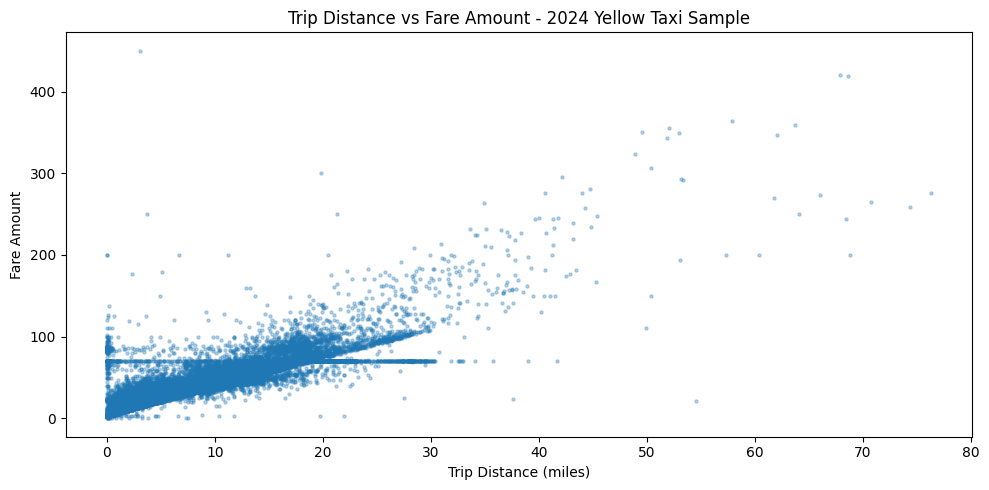

Chart saved to:
d:\UNI\Third_second\CSCI461 Introduction to Big Data\NYC_Taxi_BigData_Projec\outputs\figures\trip_distance_vs_fare_amount.png


In [28]:
distance_fare_chart_path = figures_path / "trip_distance_vs_fare_amount.png"

plt.figure(figsize=(10, 5))
plt.scatter(
    distance_fare_sample_pd["trip_distance"],
    distance_fare_sample_pd["fare_amount"],
    alpha=0.3,
    s=5
)

plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount")
plt.title("Trip Distance vs Fare Amount - 2024 Yellow Taxi Sample")
plt.tight_layout()

plt.savefig(distance_fare_chart_path)
plt.show()

print("Chart saved to:")
print(distance_fare_chart_path)

## 27. EDA: Average Fare by Pickup Hour

In this step, we calculate the average fare amount for each pickup hour.

This helps us understand whether fare amounts vary depending on the time of day.

The aggregation is performed using Spark.

In [29]:
from pyspark.sql.functions import avg

avg_fare_by_hour = clean_df.groupBy("pickup_hour") \
    .agg(avg("fare_amount").alias("average_fare")) \
    .orderBy("pickup_hour")

avg_fare_by_hour.show(24)

+-----------+------------------+
|pickup_hour|      average_fare|
+-----------+------------------+
|          0|  20.3002462341584|
|          1| 18.06565786790786|
|          2|16.568694865314637|
|          3|17.579502722881802|
|          4| 23.82151483343127|
|          5|28.514499295860777|
|          6|23.134863607006647|
|          7| 19.52926997193186|
|          8|18.565039544557614|
|          9| 18.64270890611552|
|         10| 19.02544438097204|
|         11| 19.29157260951487|
|         12| 19.71997554644162|
|         13| 20.44859540696898|
|         14| 21.23836051613087|
|         15|21.222085144964566|
|         16|21.288055158785745|
|         17|19.733377540309014|
|         18|18.437939178640452|
|         19|18.587196381093037|
|         20|18.962077162081204|
|         21|19.038236880799065|
|         22|19.651761210145086|
|         23| 20.95005211019463|
+-----------+------------------+



## 28. Visualize Average Fare by Pickup Hour

In this step, we create a bar chart showing the average fare amount for each pickup hour.

The aggregation is performed using Spark, then converted to Pandas for visualization because the result contains only 24 rows.

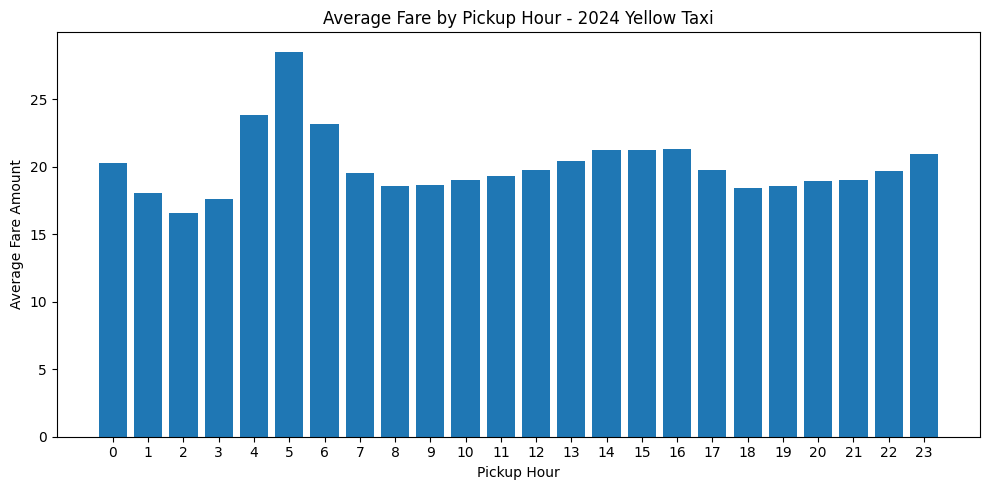

Chart saved to:
d:\UNI\Third_second\CSCI461 Introduction to Big Data\NYC_Taxi_BigData_Projec\outputs\figures\average_fare_by_pickup_hour.png


In [30]:
avg_fare_by_hour_pd = avg_fare_by_hour.toPandas()

avg_fare_hour_chart_path = figures_path / "average_fare_by_pickup_hour.png"

plt.figure(figsize=(10, 5))
plt.bar(avg_fare_by_hour_pd["pickup_hour"], avg_fare_by_hour_pd["average_fare"])
plt.xlabel("Pickup Hour")
plt.ylabel("Average Fare Amount")
plt.title("Average Fare by Pickup Hour - 2024 Yellow Taxi")
plt.xticks(range(0, 24))
plt.tight_layout()

plt.savefig(avg_fare_hour_chart_path)
plt.show()

print("Chart saved to:")
print(avg_fare_hour_chart_path)

## 29. EDA: Average Fare by Pickup Month

In this step, we calculate the average fare amount for each pickup month in 2024.

This helps us understand whether taxi fares change across the year.

The aggregation is performed using Spark.

In [31]:
avg_fare_by_month = clean_df.groupBy("pickup_month") \
    .agg(avg("fare_amount").alias("average_fare")) \
    .orderBy("pickup_month")

avg_fare_by_month.show()

+------------+------------------+
|pickup_month|      average_fare|
+------------+------------------+
|           1|18.427397428277587|
|           2|18.369105560777644|
|           3|19.144854387139468|
|           4| 19.44547413787315|
|           5|19.982984635114352|
|           6| 19.80509872128068|
|           7|20.198355449963834|
|           8|20.411635253702965|
|           9| 20.72461923329719|
|          10|20.405566144814692|
|          11| 19.65102227867125|
|          12|20.193017584377483|
+------------+------------------+



## 30. Visualize Average Fare by Pickup Month

In this step, we create a bar chart showing the average fare amount for each pickup month in 2024.

The aggregation is performed using Spark, then converted to Pandas for visualization because the result contains only 12 rows.

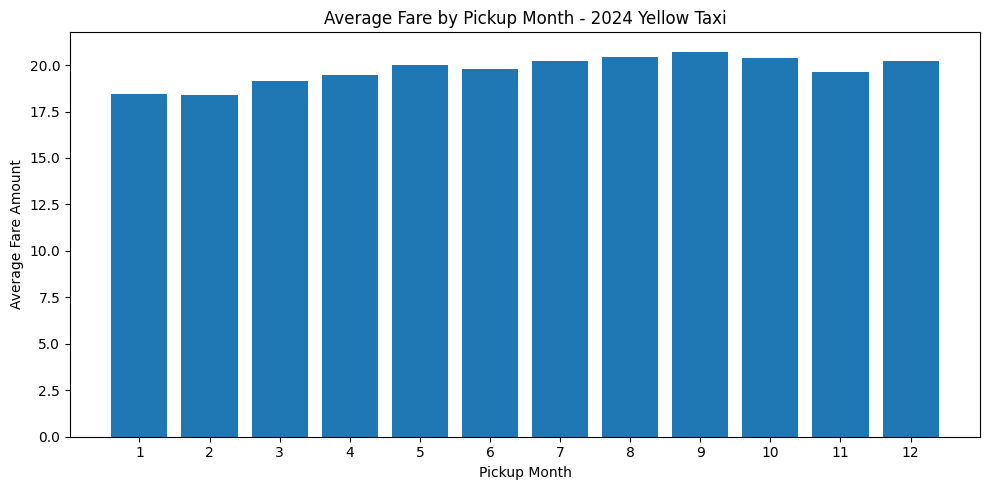

Chart saved to:
d:\UNI\Third_second\CSCI461 Introduction to Big Data\NYC_Taxi_BigData_Projec\outputs\figures\average_fare_by_pickup_month.png


In [32]:
avg_fare_by_month_pd = avg_fare_by_month.toPandas()

avg_fare_month_chart_path = figures_path / "average_fare_by_pickup_month.png"

plt.figure(figsize=(10, 5))
plt.bar(avg_fare_by_month_pd["pickup_month"], avg_fare_by_month_pd["average_fare"])
plt.xlabel("Pickup Month")
plt.ylabel("Average Fare Amount")
plt.title("Average Fare by Pickup Month - 2024 Yellow Taxi")
plt.xticks(range(1, 13))
plt.tight_layout()

plt.savefig(avg_fare_month_chart_path)
plt.show()

print("Chart saved to:")
print(avg_fare_month_chart_path)

## 31. SparkSQL Analysis

In this step, we register the cleaned DataFrame as a temporary SQL view called `taxi_trips`.

This allows us to query the data using standard SQL syntax directly inside Spark.

SparkSQL makes it easy to write readable analytical queries over large datasets without leaving the Spark environment.

In [33]:
# Register cleaned DataFrame as a temporary SQL view
clean_df.createOrReplaceTempView("taxi_trips")

print("Temporary SQL view 'taxi_trips' created successfully.")

Temporary SQL view 'taxi_trips' created successfully.


### SparkSQL Query 1: Trip Count and Average Fare by Pickup Hour

This query groups all trips by pickup hour and calculates the total number of trips and average fare for each hour.

In [34]:
sql_trips_by_hour = spark.sql("""
    SELECT
        pickup_hour,
        COUNT(*)                   AS trip_count,
        ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM taxi_trips
    GROUP BY pickup_hour
    ORDER BY pickup_hour
""")

print("SQL Query 1: Trip count and average fare by pickup hour")
sql_trips_by_hour.show(24)

SQL Query 1: Trip count and average fare by pickup hour
+-----------+----------+--------+
|pickup_hour|trip_count|avg_fare|
+-----------+----------+--------+
|          0|    953970|    20.3|
|          1|    622853|   18.07|
|          2|    405575|   16.57|
|          3|    259835|   17.58|
|          4|    166718|   23.82|
|          5|    195984|   28.51|
|          6|    458308|   23.13|
|          7|    926663|   19.53|
|          8|   1301064|   18.57|
|          9|   1507627|   18.64|
|         10|   1663010|   19.03|
|         11|   1805941|   19.29|
|         12|   1959633|   19.72|
|         13|   2031948|   20.45|
|         14|   2181772|   21.24|
|         15|   2248894|   21.22|
|         16|   2282320|   21.29|
|         17|   2454967|   19.73|
|         18|   2555714|   18.44|
|         19|   2253277|   18.59|
|         20|   2043413|   18.96|
|         21|   2066837|   19.04|
|         22|   1857893|   19.65|
|         23|   1397999|   20.95|
+-----------+----------+--

### SparkSQL Query 2: Top 10 Busiest Pickup Locations

This query finds the 10 pickup location IDs with the highest number of trips and shows the average fare for each location.

In [35]:
sql_top_locations = spark.sql("""
    SELECT
        PULocationID,
        COUNT(*)                   AS trip_count,
        ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM taxi_trips
    GROUP BY PULocationID
    ORDER BY trip_count DESC
    LIMIT 10
""")

print("SQL Query 2: Top 10 busiest pickup locations")
sql_top_locations.show()

SQL Query 2: Top 10 busiest pickup locations
+------------+----------+--------+
|PULocationID|trip_count|avg_fare|
+------------+----------+--------+
|         132|   1854148|   64.19|
|         237|   1765979|   13.06|
|         161|   1736638|   16.65|
|         236|   1557001|   13.37|
|         162|   1309258|   16.13|
|         186|   1268633|   17.38|
|         230|   1249756|   19.73|
|         138|   1244354|   44.15|
|         142|   1182020|   14.34|
|         163|   1062656|   16.73|
+------------+----------+--------+



### SparkSQL Query 3: Fare Statistics by Payment Type

This query groups trips by payment type and shows trip count, average fare, minimum fare, and maximum fare for each payment type.

In [36]:
sql_fare_by_payment = spark.sql("""
    SELECT
        payment_type,
        COUNT(*)                   AS trip_count,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(MIN(fare_amount), 2) AS min_fare,
        ROUND(MAX(fare_amount), 2) AS max_fare
    FROM taxi_trips
    GROUP BY payment_type
    ORDER BY payment_type
""")

print("SQL Query 3: Fare statistics by payment type")
sql_fare_by_payment.show()

SQL Query 3: Fare statistics by payment type
+------------+----------+--------+--------+--------+
|payment_type|trip_count|avg_fare|min_fare|max_fare|
+------------+----------+--------+--------+--------+
|           1|  29856622|   19.75|    0.01|   500.0|
|           2|   5211908|   19.58|    0.01|   500.0|
|           3|    149557|   19.78|    0.01|   500.0|
|           4|    384128|   22.14|    0.01|   500.0|
+------------+----------+--------+--------+--------+



### SparkSQL Query 4: Monthly Trip Statistics

This query calculates monthly trip counts, average fare, and average trip distance across all 12 months of 2024.

In [37]:
sql_monthly_stats = spark.sql("""
    SELECT
        pickup_month,
        COUNT(*)                        AS trip_count,
        ROUND(AVG(fare_amount),        2) AS avg_fare,
        ROUND(AVG(trip_distance),      2) AS avg_distance,
        ROUND(AVG(trip_duration_minutes), 2) AS avg_duration_min
    FROM taxi_trips
    GROUP BY pickup_month
    ORDER BY pickup_month
""")

print("SQL Query 4: Monthly trip statistics")
sql_monthly_stats.show()

SQL Query 4: Monthly trip statistics
+------------+----------+--------+------------+----------------+
|pickup_month|trip_count|avg_fare|avg_distance|avg_duration_min|
+------------+----------+--------+------------+----------------+
|           1|   2721754|   18.43|        3.29|           14.92|
|           2|   2717714|   18.37|        3.22|           15.31|
|           3|   3033901|   19.14|        3.38|           16.08|
|           4|   2985524|   19.45|        3.42|           16.42|
|           5|   3190457|   19.98|        3.45|           17.46|
|           6|   3004418|   19.81|        3.45|           17.01|
|           7|   2681165|    20.2|        3.63|           16.69|
|           8|   2601792|   20.41|         3.7|            16.8|
|           9|   3022612|   20.72|        3.57|           18.19|
|          10|   3300304|   20.41|        3.49|           17.76|
|          11|   3144622|   19.65|        3.33|           17.19|
|          12|   3197952|   20.19|        3.32|      

## 32. Window Functions Analysis

In this step, we use Spark Window Functions to compute analytics that require ordering and partitioning over rows.

Window functions allow us to calculate values relative to other rows in the same partition without collapsing the DataFrame.

We will use:

- `rank()` — rank each pickup hour by trip count within each month
- `lag()` — compare average fare of the current hour with the previous hour
- `lead()` — compare average fare of the current hour with the next hour

In [38]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, lag, lead, avg, count

# Aggregate: trips and average fare per month and hour
hourly_monthly_stats = clean_df.groupBy("pickup_month", "pickup_hour") \
    .agg(
        count("*").alias("trip_count"),
        avg("fare_amount").alias("avg_fare")
    ) \
    .orderBy("pickup_month", "pickup_hour")

print("Hourly stats aggregated. Sample:")
hourly_monthly_stats.show(10)

Hourly stats aggregated. Sample:
+------------+-----------+----------+------------------+
|pickup_month|pickup_hour|trip_count|          avg_fare|
+------------+-----------+----------+------------------+
|           1|          0|     69104| 19.68861657791156|
|           1|          1|     45324|17.346989453710858|
|           1|          2|     31895|16.349661075403688|
|           1|          3|     20524|17.872881504580025|
|           1|          4|     12760|22.969045454545416|
|           1|          5|     15621|27.582329556366197|
|           1|          6|     35561|21.975800174348244|
|           1|          7|     74266|18.522258637869424|
|           1|          8|    105062| 17.57883668690897|
|           1|          9|    119311|17.847054001726946|
+------------+-----------+----------+------------------+
only showing top 10 rows


### Apply rank(), lag(), and lead() Window Functions

We define two windows:

- One partitioned by `pickup_month`, ordered by `trip_count` descending — used for `rank()`
- One partitioned by `pickup_month`, ordered by `pickup_hour` ascending — used for `lag()` and `lead()`

In [39]:
# Window: partitioned by month, ordered by trip count descending (for rank)
window_by_count = Window.partitionBy("pickup_month").orderBy(col("trip_count").desc())

# Window: partitioned by month, ordered by pickup_hour ascending (for lag/lead)
window_by_hour  = Window.partitionBy("pickup_month").orderBy(col("pickup_hour").asc())

# Apply window functions
hourly_window_df = hourly_monthly_stats \
    .withColumn("rank_by_trips",        rank().over(window_by_count)) \
    .withColumn("prev_hour_avg_fare",   lag("avg_fare",  1).over(window_by_hour)) \
    .withColumn("next_hour_avg_fare",   lead("avg_fare", 1).over(window_by_hour)) \
    .withColumn(
        "fare_change_from_prev",
        col("avg_fare") - col("prev_hour_avg_fare")
    )

print("Window functions applied successfully.")
print("Showing rank, lag, and lead results for January (month=1):")
hourly_window_df.filter(col("pickup_month") == 1).orderBy("pickup_hour").show(24)

Window functions applied successfully.
Showing rank, lag, and lead results for January (month=1):
+------------+-----------+----------+------------------+-------------+------------------+------------------+---------------------+
|pickup_month|pickup_hour|trip_count|          avg_fare|rank_by_trips|prev_hour_avg_fare|next_hour_avg_fare|fare_change_from_prev|
+------------+-----------+----------+------------------+-------------+------------------+------------------+---------------------+
|           1|          0|     69104| 19.68861657791156|           18|              NULL|17.346989453710858|                 NULL|
|           1|          1|     45324|17.346989453710858|           19| 19.68861657791156|16.349661075403688|   -2.341627124200702|
|           1|          2|     31895|16.349661075403688|           21|17.346989453710858|17.872881504580025|    -0.99732837830717|
|           1|          3|     20524|17.872881504580025|           22|16.349661075403688|22.969045454545416|   1.523

### Busiest Hour Per Month

Using the `rank_by_trips` column, we can identify the busiest hour in each month.

In [40]:
# Show busiest hour per month (rank = 1)
busiest_hour_per_month = hourly_window_df \
    .filter(col("rank_by_trips") == 1) \
    .select("pickup_month", "pickup_hour", "trip_count", "avg_fare") \
    .orderBy("pickup_month")

print("Busiest hour per month (rank = 1 by trip count):")
busiest_hour_per_month.show()

Busiest hour per month (rank = 1 by trip count):
+------------+-----------+----------+------------------+
|pickup_month|pickup_hour|trip_count|          avg_fare|
+------------+-----------+----------+------------------+
|           1|         18|    195791| 16.94348616637098|
|           2|         18|    202060| 17.05331822231035|
|           3|         18|    212894|17.745866299660914|
|           4|         18|    214063|18.256649771329013|
|           5|         18|    228775|18.456515222380357|
|           6|         18|    213464|18.435080294569108|
|           7|         18|    191376|18.995747429144945|
|           8|         18|    185516| 18.95071724271761|
|           9|         18|    218087|19.532976793665227|
|          10|         18|    240357|19.180782253064834|
|          11|         18|    227257| 18.26606295955682|
|          12|         18|    226074|19.210705786600556|
+------------+-----------+----------+------------------+



## 33. Select Features for Machine Learning

In this step, we select the columns that will be used for fare prediction.

The target variable is `fare_amount`.

The input features are selected from cleaned and engineered trip-related columns.

Selected features:

- `trip_distance`
- `trip_duration_minutes`
- `passenger_count`
- `pickup_hour`
- `pickup_day`
- `pickup_month`
- `is_weekend`
- `payment_type`
- `PULocationID`
- `DOLocationID`

The column `fare_per_mile` is not used as a model input because it is calculated using `fare_amount`, which is the target variable.

In [41]:
model_columns = [
    "trip_distance",
    "trip_duration_minutes",
    "passenger_count",
    "pickup_hour",
    "pickup_day",
    "pickup_month",
    "is_weekend",
    "payment_type",
    "PULocationID",
    "DOLocationID",
    "fare_amount"
]

model_df = clean_df.select(model_columns)

print("Model dataset columns:")
print(model_df.columns)

Model dataset columns:
['trip_distance', 'trip_duration_minutes', 'passenger_count', 'pickup_hour', 'pickup_day', 'pickup_month', 'is_weekend', 'payment_type', 'PULocationID', 'DOLocationID', 'fare_amount']


## 34. Assemble Feature Columns

In this step, we use Spark MLlib's `VectorAssembler` to combine the selected input columns into a single feature vector column.

Spark MLlib models require input features to be stored in one vector column, usually called `features`.

The target column remains `fare_amount`.

In [42]:
from pyspark.ml.feature import VectorAssembler

feature_columns = [
    "trip_distance",
    "trip_duration_minutes",
    "passenger_count",
    "pickup_hour",
    "pickup_day",
    "pickup_month",
    "is_weekend",
    "payment_type",
    "PULocationID",
    "DOLocationID"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

model_ready_df = assembler.transform(model_df).select("features", "fare_amount")

print("Feature vector created successfully.")
model_ready_df.show(5, truncate=False)

Feature vector created successfully.
+---------------------------------------------------------------+-----------+
|features                                                       |fare_amount|
+---------------------------------------------------------------+-----------+
|[6.1,24.583333333333332,1.0,0.0,4.0,5.0,0.0,1.0,138.0,145.0]   |28.2       |
|[11.23,31.266666666666666,1.0,23.0,3.0,4.0,0.0,1.0,138.0,249.0]|46.4       |
|[9.02,16.966666666666665,1.0,0.0,4.0,5.0,0.0,1.0,138.0,170.0]  |35.9       |
|[6.53,24.066666666666666,1.0,0.0,4.0,5.0,0.0,1.0,87.0,133.0]   |30.3       |
|[14.38,40.833333333333336,1.0,0.0,4.0,5.0,0.0,1.0,161.0,165.0] |61.8       |
+---------------------------------------------------------------+-----------+
only showing top 5 rows


## 35. Split Data into Training and Testing Sets

In this step, we split the prepared dataset into training and testing sets.

The training set is used to train the fare prediction model.

The testing set is used to evaluate how well the model performs on unseen data.

We use an 80/20 split:

- 80% training data
- 20% testing data

In [43]:
train_df, test_df = model_ready_df.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_df.count())
print("Testing rows:",  test_df.count())

Training rows: 28480061
Testing rows: 7122154


## 36. Train Fare Prediction Model Using Spark MLlib

In this step, we train a regression model using Spark MLlib.

The model is trained to predict `fare_amount` using the selected trip-related features.

We start with Linear Regression because it is simple, interpretable, and suitable as a baseline regression model.

In [44]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="fare_amount",
    predictionCol="prediction"
)

lr_model = lr.fit(train_df)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 37. Generate Predictions on the Test Set

In this step, we use the trained Linear Regression model to generate fare predictions on the testing dataset.

The testing dataset was not used during training, so it helps evaluate how well the model performs on unseen data.

In [45]:
predictions = lr_model.transform(test_df)

predictions.select("fare_amount", "prediction").show(10)

print("Predictions generated successfully.")

+-----------+------------------+
|fare_amount|        prediction|
+-----------+------------------+
|       15.0| 4.517081599308973|
|       84.0|4.4329585958219475|
|       70.0|  4.49611106072475|
|       90.0| 4.516486262463609|
|        3.0| 4.965776842939139|
|        3.0| 5.125901853902899|
|       85.0| 4.399962662267739|
|        3.0| 4.935586843029801|
|        3.0| 4.842712355095561|
|        3.0| 4.860203722199774|
+-----------+------------------+
only showing top 10 rows
Predictions generated successfully.


## 38. Evaluate the Fare Prediction Model

In this step, we evaluate the Linear Regression model using regression metrics.

The metrics used are:

- Mean Absolute Error, which shows the average absolute prediction error
- Root Mean Squared Error, which penalizes larger errors more strongly
- R² Score, which shows how much variation in fare amount is explained by the model

These metrics help us judge whether the model performs well on the testing data.

In [46]:
from pyspark.ml.evaluation import RegressionEvaluator

mae_evaluator = RegressionEvaluator(
    labelCol="fare_amount", predictionCol="prediction", metricName="mae"
)
rmse_evaluator = RegressionEvaluator(
    labelCol="fare_amount", predictionCol="prediction", metricName="rmse"
)
r2_evaluator = RegressionEvaluator(
    labelCol="fare_amount", predictionCol="prediction", metricName="r2"
)

mae  = mae_evaluator.evaluate(predictions)
rmse = rmse_evaluator.evaluate(predictions)
r2   = r2_evaluator.evaluate(predictions)

print("Model Evaluation Results")
print("------------------------")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Results
------------------------
MAE: 2.1607
RMSE: 5.9255
R² Score: 0.8934


## 39. Save Model Evaluation Results

In this step, we save the model evaluation metrics to a text file.

This output will be used later in the final report and technical documentation.

In [47]:
model_results_path = MODEL_DIR / "linear_regression_metrics.txt"

with open(model_results_path, "w", encoding="utf-8") as file:
    file.write("NYC Yellow Taxi Fare Prediction - Linear Regression Results\n")
    file.write("=" * 60 + "\n\n")
    file.write(f"Training rows: 28480061\n")
    file.write(f"Testing rows: 7122154\n\n")
    file.write(f"MAE: {mae:.4f}\n")
    file.write(f"RMSE: {rmse:.4f}\n")
    file.write(f"R² Score: {r2:.4f}\n")

print("Model evaluation results saved to:")
print(model_results_path)

## 40. Spark ML Pipeline

In this step, we rebuild the fare prediction model using a Spark ML **Pipeline**.

A Pipeline chains multiple stages — in this case `VectorAssembler` and `LinearRegression` — into a single object that can be fit on training data and used to transform test data.

Using a Pipeline is the recommended approach in Spark MLlib because:

- It keeps preprocessing and modeling in one reusable workflow
- It prevents data leakage (transformations are only fitted on training data)
- It makes the model easier to save, load, and deploy

In [48]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Define feature columns
pipeline_feature_cols = [
    "trip_distance",
    "trip_duration_minutes",
    "passenger_count",
    "pickup_hour",
    "pickup_day",
    "pickup_month",
    "is_weekend",
    "payment_type",
    "PULocationID",
    "DOLocationID"
]

# Select relevant columns for the pipeline model
pipeline_df = clean_df.select(pipeline_feature_cols + ["fare_amount"])

# Split into training and testing sets
pipeline_train_df, pipeline_test_df = pipeline_df.randomSplit([0.8, 0.2], seed=42)

print("Pipeline training rows:", pipeline_train_df.count())
print("Pipeline testing rows:",  pipeline_test_df.count())

Pipeline training rows: 28480061
Pipeline testing rows: 7122154


### Define Pipeline Stages

The Pipeline has two stages:

1. **VectorAssembler** — combines feature columns into a single `features` vector column
2. **LinearRegression** — trains a regression model using the `features` vector to predict `fare_amount`

The Pipeline is fitted on the training data only.

In [49]:
# Stage 1: VectorAssembler
pipeline_assembler = VectorAssembler(
    inputCols=pipeline_feature_cols,
    outputCol="features"
)

# Stage 2: LinearRegression
pipeline_lr = LinearRegression(
    featuresCol="features",
    labelCol="fare_amount",
    predictionCol="prediction"
)

# Build the Pipeline
pipeline = Pipeline(stages=[pipeline_assembler, pipeline_lr])

# Fit the Pipeline on training data
pipeline_model = pipeline.fit(pipeline_train_df)

print("Spark ML Pipeline trained successfully.")
print("Pipeline stages:", [type(s).__name__ for s in pipeline.getStages()])

Spark ML Pipeline trained successfully.
Pipeline stages: ['VectorAssembler', 'LinearRegression']


### Generate Predictions and Evaluate the Pipeline Model

We use the fitted Pipeline to generate predictions on the test set and evaluate the model using the same regression metrics as before.

In [50]:
# Generate predictions using the Pipeline model
pipeline_predictions = pipeline_model.transform(pipeline_test_df)

pipeline_predictions.select("fare_amount", "prediction").show(10)

# Evaluate Pipeline model
pipeline_mae = RegressionEvaluator(
    labelCol="fare_amount", predictionCol="prediction", metricName="mae"
).evaluate(pipeline_predictions)

pipeline_rmse = RegressionEvaluator(
    labelCol="fare_amount", predictionCol="prediction", metricName="rmse"
).evaluate(pipeline_predictions)

pipeline_r2 = RegressionEvaluator(
    labelCol="fare_amount", predictionCol="prediction", metricName="r2"
).evaluate(pipeline_predictions)

print("\nSpark ML Pipeline - Model Evaluation Results")
print("--------------------------------------------")
print(f"MAE:      {pipeline_mae:.4f}")
print(f"RMSE:     {pipeline_rmse:.4f}")
print(f"R² Score: {pipeline_r2:.4f}")

+-----------+------------------+
|fare_amount|        prediction|
+-----------+------------------+
|       15.0| 4.517081599308973|
|       84.0|4.4329585958219475|
|       70.0|  4.49611106072475|
|       90.0| 4.516486262463609|
|        3.0| 4.965776842939139|
|        3.0| 5.125901853902899|
|       85.0| 4.399962662267739|
|        3.0| 4.935586843029801|
|        3.0| 4.842712355095561|
|        3.0| 4.860203722199774|
+-----------+------------------+
only showing top 10 rows

Spark ML Pipeline - Model Evaluation Results
--------------------------------------------
MAE:      2.1607
RMSE:     5.9255
R² Score: 0.8934


### Save the Pipeline Model

We save the fitted Pipeline model to disk so it can be reloaded later without retraining.

In [51]:
# Save fitted Pipeline model to HDFS
pipeline_model.write().overwrite().save(HDFS_MODEL)

print("Pipeline model saved to HDFS:")
print("  Path:", HDFS_MODEL)

## 41. Phase 3 Preprocessing, EDA, and Modeling Summary

This notebook completed the main Phase 3 implementation for the NYC Taxi Fare Prediction project.

The full 2024 Yellow Taxi dataset was loaded using Spark from 12 monthly Parquet files. The raw dataset originally contained `41,169,720` rows and `19` columns.

During preprocessing, invalid timestamps, invalid trip durations, invalid numeric values, missing values, and extreme outliers were handled. After preprocessing and feature engineering, the cleaned dataset contained `35,602,215` rows and `25` columns.

New features created in this notebook include:

- `trip_duration_minutes`
- `pickup_hour`
- `pickup_day`
- `pickup_month`
- `is_weekend`
- `fare_per_mile`

The cleaned dataset was saved to:

`data/processed/cleaned_yellow_2024`

Exploratory data analysis was performed using Spark aggregations and sampled visualizations. The EDA showed patterns in trip demand by pickup hour, fare distribution, trip distance distribution, the relationship between trip distance and fare amount, and average fare by time.

SparkSQL was used to register the cleaned dataset as a temporary view and run SQL queries for:
- Trip count and average fare by pickup hour
- Top 10 busiest pickup locations
- Fare statistics by payment type
- Monthly trip statistics

Window Functions were applied using `rank()`, `lag()`, and `lead()` to:
- Rank the busiest hour per month by trip count
- Compare average fare with the previous and next hour

A Linear Regression model was trained using Spark MLlib to predict `fare_amount`.

The model used the following input features:

- `trip_distance`
- `trip_duration_minutes`
- `passenger_count`
- `pickup_hour`
- `pickup_day`
- `pickup_month`
- `is_weekend`
- `payment_type`
- `PULocationID`
- `DOLocationID`

The model was evaluated on the testing dataset with the following results:

| Metric | Value |
|---|---:|
| MAE | `2.1607` |
| RMSE | `5.9255` |
| R² Score | `0.8934` |

A Spark ML Pipeline was also built, wrapping `VectorAssembler` and `LinearRegression` into a single reusable pipeline object. The pipeline model was saved to:

`outputs/model_results/lr_pipeline_model`

In [52]:
spark.stop()

print("Spark session stopped.")

Spark session stopped.
